In [1]:
import os

# Create main folder
main_folder = "/content/PlantBot"
os.makedirs(main_folder, exist_ok=True)

print(f"Folder created at: {main_folder}")


Folder created at: /content/PlantBot


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
source_path = "/content/drive/MyDrive/Datasets/PlantVillage"


In [4]:
import os
import shutil

# Define dataset folder properly
dataset_folder = "/content/PlantBot/Datasets"

# Make sure it exists
os.makedirs(dataset_folder, exist_ok=True)

# Your dataset source path (you changed this)
source_path = "/content/drive/MyDrive/Datasets/PlantVillage"

# Copy dataset
shutil.copytree(source_path, dataset_folder, dirs_exist_ok=True)

print("Dataset copied successfully")


Dataset copied successfully


In [5]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd


In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


In [7]:
BASE_PATH = "/content/PlantBot/Datasets"
TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH = os.path.join(BASE_PATH, "val")


# CLASS DISTRIBUTION COUNT
count images in each classes


In [8]:
def class_distribution(path):
    data = []
    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            data.append([cls, len(os.listdir(cls_path))])
    return pd.DataFrame(data, columns=["Class", "Image_Count"]).sort_values(
        by="Image_Count", ascending=False
    )


In [9]:
train_df = class_distribution(TRAIN_PATH)
print("TRAIN CLASS DISTRIBUTION")
train_df


TRAIN CLASS DISTRIBUTION


,Class,Image_Count
31,Orange___Haunglongbing_(Citrus_greening),4405
25,Tomato___Tomato_Yellow_Leaf_Curl_Virus,4296
5,Soybean___healthy,4072
30,Peach___Bacterial_spot,1838
18,Tomato___Bacterial_spot,1702
1,Tomato___Late_blight,1527
20,Squash___Powdery_mildew,1468
19,Tomato___Septoria_leaf_spot,1417
32,Tomato___Spider_mites Two-spotted_spider_mite,1341
36,Apple___healthy,1316


CLASS DISTRIBUTION ANALYSIS


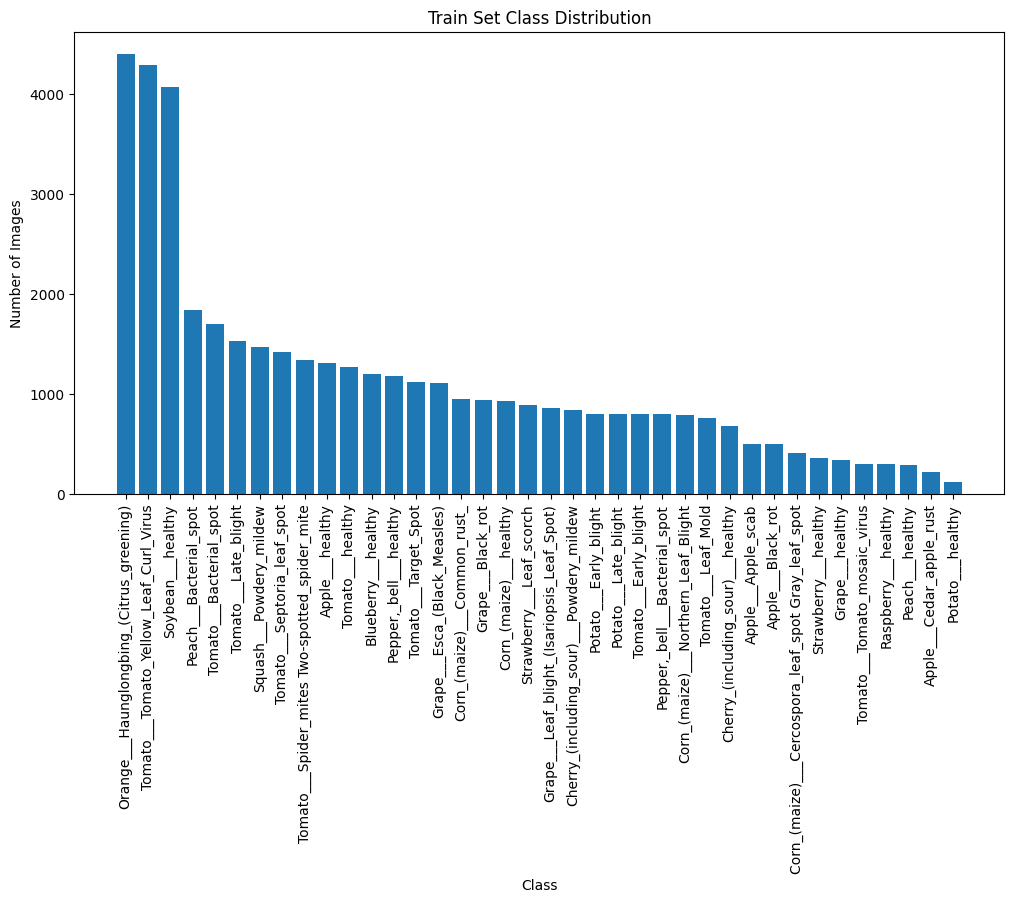

In [10]:
plt.figure(figsize=(12,6))
plt.bar(train_df["Class"], train_df["Image_Count"])
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Train Set Class Distribution")
plt.show()


# IMAGE RESOLUTION ANALYSIS

Aspects ratio analysis


In [11]:
def image_resolution_analysis(path):
    widths, heights, ratios = [], [], []

    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            for img_name in os.listdir(cls_path):
                img_path = os.path.join(cls_path, img_name)
                try:
                    img = Image.open(img_path)
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
                    ratios.append(w / h)
                except:
                    pass

    return pd.DataFrame({
        "Width": widths,
        "Height": heights,
        "Aspect_Ratio": ratios
    })


In [12]:
train_img_df = image_resolution_analysis(TRAIN_PATH)
print("TRAIN IMAGE RESOLUTION STATS")
train_img_df.describe()


TRAIN IMAGE RESOLUTION STATS


,Width,Height,Aspect_Ratio
count,43457.0,43457.0,43457.0
mean,256.0,256.0,1.0
std,0.0,0.0,0.0
min,256.0,256.0,1.0
25%,256.0,256.0,1.0
50%,256.0,256.0,1.0
75%,256.0,256.0,1.0
max,256.0,256.0,1.0


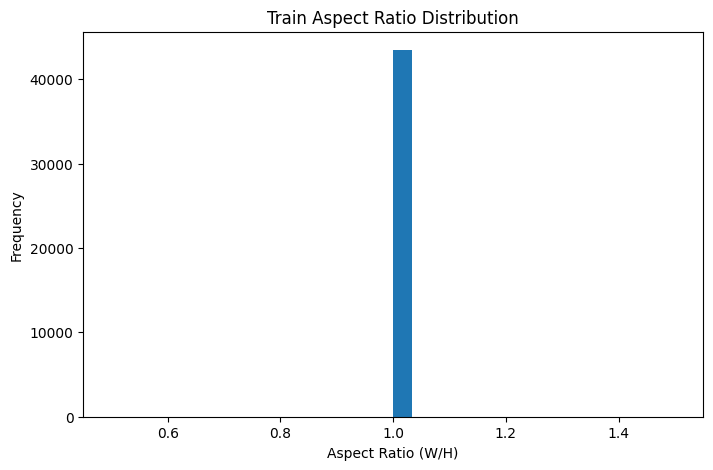

In [13]:
plt.figure(figsize=(8,5))
plt.hist(train_img_df["Aspect_Ratio"], bins=30)
plt.xlabel("Aspect Ratio (W/H)")
plt.ylabel("Frequency")
plt.title("Train Aspect Ratio Distribution")
plt.show()


In [14]:
import os
print(len(os.listdir(TRAIN_PATH)), "classes in train")
print(len(os.listdir(VAL_PATH)), "classes in val")


38 classes in train
38 classes in val


In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def class_distribution(path):
    data = []
    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            data.append({"Class": cls, "Image_Count": count})
    return pd.DataFrame(data).sort_values(by="Image_Count", ascending=False)

# Create dataframes
train_df = class_distribution(TRAIN_PATH)
val_df   = class_distribution(VAL_PATH)

train_df.head(), val_df.head()


(                                       Class  Image_Count
 31  Orange___Haunglongbing_(Citrus_greening)         4405
 25    Tomato___Tomato_Yellow_Leaf_Curl_Virus         4296
 5                          Soybean___healthy         4072
 30                    Peach___Bacterial_spot         1838
 18                   Tomato___Bacterial_spot         1702,
                                        Class  Image_Count
 31  Orange___Haunglongbing_(Citrus_greening)         1102
 25    Tomato___Tomato_Yellow_Leaf_Curl_Virus         1071
 5                          Soybean___healthy         1018
 30                    Peach___Bacterial_spot          459
 18                   Tomato___Bacterial_spot          425)

# IMAGE DIMENSION ANALYSIS

In [16]:
train_img_df[["Width", "Height"]].describe()


,Width,Height
count,43457.0,43457.0
mean,256.0,256.0
std,0.0,0.0
min,256.0,256.0
25%,256.0,256.0
50%,256.0,256.0
75%,256.0,256.0
max,256.0,256.0


# DISTRIBUTION OF IMAGE WIDTH AND HEIGHT

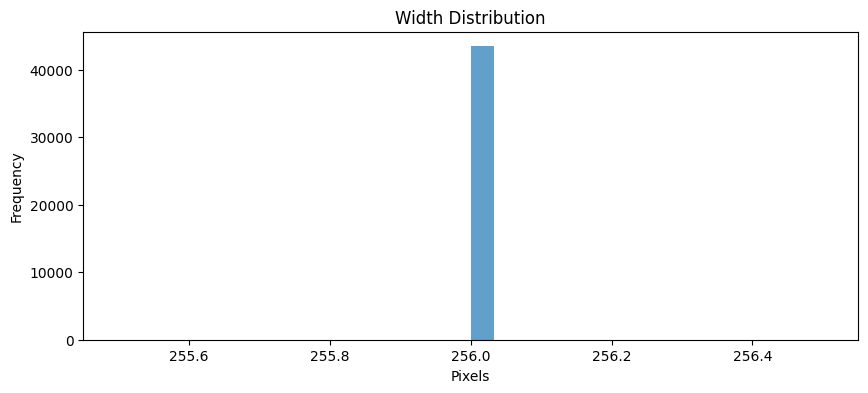

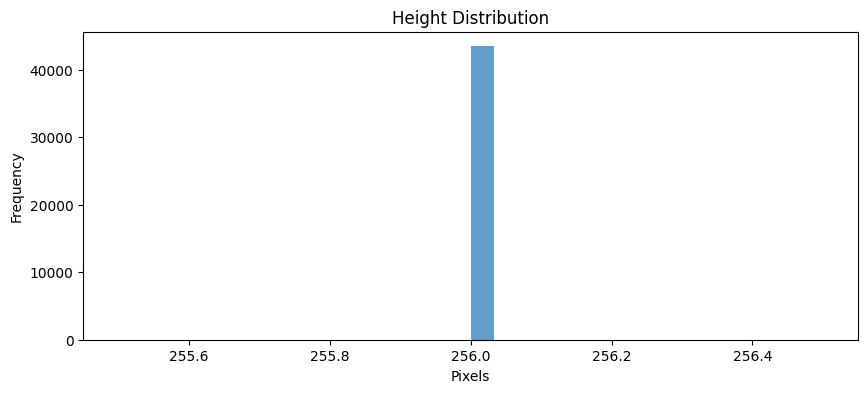

In [17]:
plt.figure(figsize=(10,4))
plt.hist(train_img_df["Width"], bins=30, alpha=0.7)
plt.title("Width Distribution")
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10,4))
plt.hist(train_img_df["Height"], bins=30, alpha=0.7)
plt.title("Height Distribution")
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.show()


In [18]:
train_img_df["Width"].value_counts().head()
train_img_df["Height"].value_counts().head()


,count
Height,
256,43457


# COLOR SPACE ANALYSIS

In [19]:
from PIL import Image
import os

def check_color_mode(path, name):
    modes = set()

    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            for img_name in os.listdir(cls_path):
                img_path = os.path.join(cls_path, img_name)
                try:
                    with Image.open(img_path) as img:
                        modes.add(img.mode)
                except:
                    pass
            break  # one class is enough (all are same)

    print(f"{name} image modes:", modes)

check_color_mode(TRAIN_PATH, "Train")
check_color_mode(VAL_PATH, "Validation")


Train image modes: {'RGB'}
Validation image modes: {'RGB'}


In [20]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter

In [21]:
TRAIN_PATH = "/content/PlantBot/Datasets/train"
VAL_PATH   = "/content/PlantBot/Datasets/val"

# TRAIN TRANFORMS (with augmentation)

In [22]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [23]:
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load datasets
Labels are automatically assigned from folder names

In [24]:
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_PATH, transform=val_transforms)

print("Classes:", train_dataset.classes)
print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))

Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___

# Handle Class Imbalance
Count images per class

In [25]:
targets = train_dataset.targets
class_count = Counter(targets)
print("Class counts:", class_count)

Class counts: Counter({15: 4405, 35: 4296, 24: 4072, 16: 1838, 28: 1702, 30: 1527, 25: 1468, 32: 1417, 33: 1341, 3: 1316, 37: 1276, 4: 1202, 19: 1183, 34: 1123, 12: 1107, 8: 953, 11: 944, 10: 929, 26: 887, 13: 861, 5: 842, 20: 800, 21: 800, 29: 800, 18: 797, 9: 788, 31: 761, 6: 684, 0: 504, 1: 496, 7: 410, 27: 364, 14: 339, 36: 299, 23: 297, 17: 288, 2: 220, 22: 121})


Compute weights

In [26]:
num_samples = len(train_dataset)

class_weights = []
for i in range(len(class_count)):
    class_weights.append(num_samples / class_count[i])

class_weights = torch.FloatTensor(class_weights)

# Create sample weights

In [27]:
sample_weights = [class_weights[label] for label in targets]
sample_weights = torch.DoubleTensor(sample_weights)

Weighted Random Sampler

In [28]:
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Create DataLoaders

In [29]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

In [30]:
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Final Check

In [31]:
images, labels = next(iter(train_loader))
print(images.shape)   # [32, 3, 224, 224]
print(labels.shape)   # [32]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([32, 3, 224, 224])
torch.Size([32])


# VISUALIZE SAMPLE BATCHES (TRAIN & VAL)

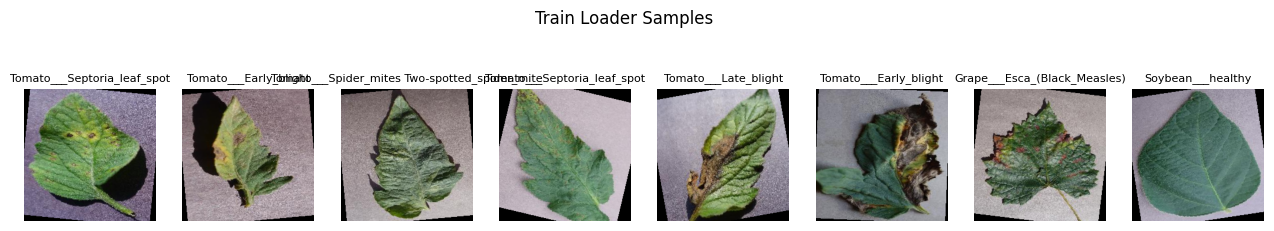

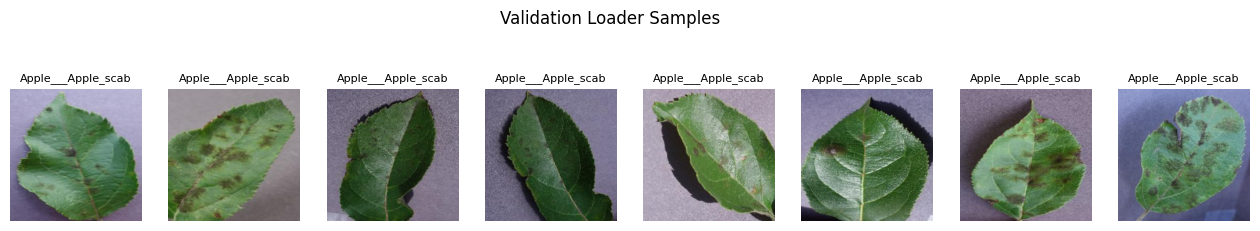

In [32]:
import torch
import matplotlib.pyplot as plt

# Denormalization function (ONLY for visualization)
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean
    return img.clamp(0, 1)


def show_batch(loader, class_names, title):
    images, labels = next(iter(loader))

    images = images[:8]
    labels = labels[:8]

    fig, axes = plt.subplots(1, 8, figsize=(16, 3))
    for i in range(8):
        img = denormalize(images[i])
        img = img.permute(1, 2, 0)
        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i]], fontsize=8)
        axes[i].axis("off")

    plt.suptitle(title)
    plt.show()


# Show batches
show_batch(train_loader, train_dataset.classes, "Train Loader Samples")
show_batch(val_loader, val_dataset.classes, "Validation Loader Samples")

In [33]:
import torch.optim as optim
from tqdm import tqdm
import torch.nn as nn
from torchsummary import summary

In [34]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [35]:
class SampleNN(nn.Module):
    def __init__(self, input_size, hidden_units, num_classes):
        super(SampleNN, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, num_classes)
        )

    def forward(self, x):
        return self.model(x)

input_size = 224 * 224 * 3
hidden_units = 128
num_classes = len(train_dataset.classes)
model = SampleNN(input_size, hidden_units, num_classes).to(device)
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1               [-1, 150528]               0
            Linear-2                  [-1, 128]      19,267,712
              ReLU-3                  [-1, 128]               0
            Linear-4                   [-1, 38]           4,902
Total params: 19,272,614
Trainable params: 19,272,614
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 1.15
Params size (MB): 73.52
Estimated Total Size (MB): 75.24
----------------------------------------------------------------


In [36]:
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [37]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc="Training"):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [38]:
from tqdm import tqdm
import torch

def validate_one_epoch(model, val_loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [39]:
import torch.nn as nn

# Loss Function
criterion = nn.CrossEntropyLoss()

num_epochs = 5

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    print(f"Epoch [{epoch+1}/{num_epochs}]")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    scheduler.step()

print("Training complete!")

Epoch [1/5]


Validation: 100%|██████████| 340/340 [00:45<00:00,  7.47it/s]


Train Loss: 4.2361, Train Acc: 0.1231
Val Loss: 7.0015, Val Acc: 0.1688
Epoch [2/5]


Validation: 100%|██████████| 340/340 [00:44<00:00,  7.62it/s]


Train Loss: 3.3703, Train Acc: 0.1784
Val Loss: 7.0848, Val Acc: 0.2295
Epoch [3/5]


...

Train Loss: 3.1694, Train Acc: 0.2328
Val Loss: 6.5192, Val Acc: 0.2476
Epoch [4/5]


Validation: 100%|██████████| 340/340 [00:44<00:00,  7.62it/s]


Train Loss: 2.8409, Train Acc: 0.2740
Val Loss: 6.5048, Val Acc: 0.2944
Epoch [5/5]


Validation: 100%|██████████| 340/340 [00:43<00:00,  7.73it/s]

Train Loss: 2.6863, Train Acc: 0.3124
Val Loss: 9.2271, Val Acc: 0.2955
Training complete!


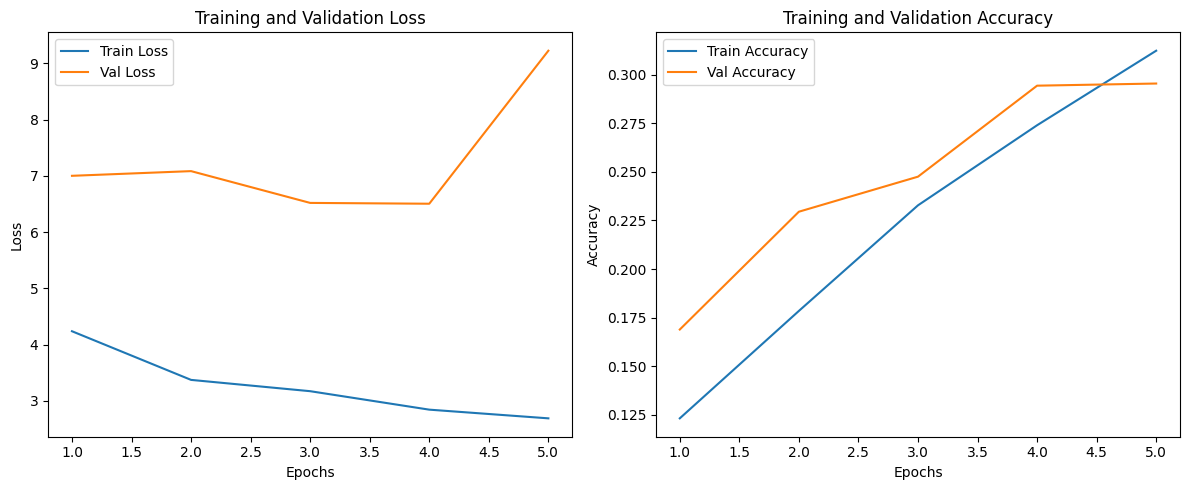

In [40]:
import matplotlib.pyplot as plt

# Epoch numbers
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# -------- Loss Plot --------
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# -------- Accuracy Plot --------
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
import random
import torch
import matplotlib.pyplot as plt

def test_model_on_samples(model, dataset, class_names, num_samples=2, device='cuda'):

    model.eval()

    sample_indices = random.sample(range(len(dataset)), num_samples)

    fig, axes = plt.subplots(1, num_samples, figsize=(5 * num_samples, 5))

    if num_samples == 1:
        axes = [axes]

    with torch.no_grad():
        for idx, sample_idx in enumerate(sample_indices):

            image, true_label = dataset[sample_idx]
            true_class_name = class_names[true_label]

            image_batch = image.unsqueeze(0).to(device)

            output = model(image_batch)
            probabilities = torch.softmax(output, dim=1)
            pred_prob, pred_label = torch.max(probabilities, 1)

            pred_class_name = class_names[pred_label.item()]

            # --------- DENORMALIZE (ImageNet standard) ----------
            mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
            std = torch.tensor([0.229, 0.224, 0.225]).to(device)

            img = image.clone().to(device)
            img = img * std[:, None, None] + mean[:, None, None]
            img = torch.clamp(img, 0, 1)

            img_display = img.permute(1, 2, 0).cpu().numpy()
            # ----------------------------------------------------

            axes[idx].imshow(img_display)
            axes[idx].axis('off')

            color = 'green' if pred_label.item() == true_label else 'red'

            title = f"True: {true_class_name}\n"
            title += f"Pred: {pred_class_name}\n"
            title += f"Confidence: {pred_prob.item()*100:.1f}%"

            axes[idx].set_title(title, fontsize=10, color=color, weight='bold')

    plt.tight_layout()
    plt.show()

In [42]:
class_names = val_dataset.classes
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [43]:

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": train_dataset.classes,
    "num_classes": num_classes
}, "best_simplecnn_model.pth")


In [46]:


class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        # Feature Extraction
        self.features = nn.Sequential(

            # -------- Block 1 --------
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 224 -> 112

            # -------- Block 2 --------
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 112 -> 56

            # -------- Block 3 --------
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)    # 56 -> 28
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [47]:
import torch.optim as optim

learning_rate = 0.0001

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print(f"Optimizer: Adam(lr={learning_rate}, weight_decay=1e-4)")
print("Scheduler: ReduceLROnPlateau (reduces LR when validation loss plateaus)")

Optimizer: Adam(lr=0.0001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (reduces LR when validation loss plateaus)


In [48]:
num_epochs = 5

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_acc = 0.0

for epoch in range(num_epochs):

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print("-" * 50)

    # -------- Train --------
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # -------- Validate --------
    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Print results
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

    # -------- Step Scheduler --------
    scheduler.step(val_loss)

    # Print current learning rate
    print("Current Learning Rate:", optimizer.param_groups[0]['lr'])

    # -------- Save Best Model --------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_simplecnn_model.pth')
        print(f"✅ Best model saved! Val Acc: {val_acc*100:.2f}%")

print("\n" + "=" * 50)
print(f"Training complete! Best Val Accuracy: {best_val_acc*100:.2f}%")


Epoch [1/5]
--------------------------------------------------


Validation: 100%|██████████| 340/340 [00:46<00:00,  7.26it/s]


Train Loss: 2.0772 | Train Acc: 41.09%
Val Loss:   4.0950 | Val Acc:   36.20%
Current Learning Rate: 0.0001
✅ Best model saved! Val Acc: 36.20%

Epoch [2/5]
--------------------------------------------------


Validation: 100%|██████████| 340/340 [00:45<00:00,  7.40it/s]


Train Loss: 1.8243 | Train Acc: 45.94%
Val Loss:   3.4956 | Val Acc:   36.27%
Current Learning Rate: 0.0001
✅ Best model saved! Val Acc: 36.27%

Epoch [3/5]
--------------------------------------------------


...

Train Loss: 1.6799 | Train Acc: 49.98%
Val Loss:   2.9498 | Val Acc:   38.93%
Current Learning Rate: 0.0001
✅ Best model saved! Val Acc: 38.93%

Epoch [4/5]
--------------------------------------------------


Validation: 100%|██████████| 340/340 [00:49<00:00,  6.84it/s]


Train Loss: 1.5462 | Train Acc: 53.87%
Val Loss:   2.6995 | Val Acc:   40.97%
Current Learning Rate: 0.0001
✅ Best model saved! Val Acc: 40.97%

Epoch [5/5]
--------------------------------------------------


Validation: 100%|██████████| 340/340 [00:46<00:00,  7.34it/s]


Train Loss: 1.4473 | Train Acc: 57.18%
Val Loss:   2.5185 | Val Acc:   44.59%
Current Learning Rate: 0.0001
✅ Best model saved! Val Acc: 44.59%

Training complete! Best Val Accuracy: 44.59%


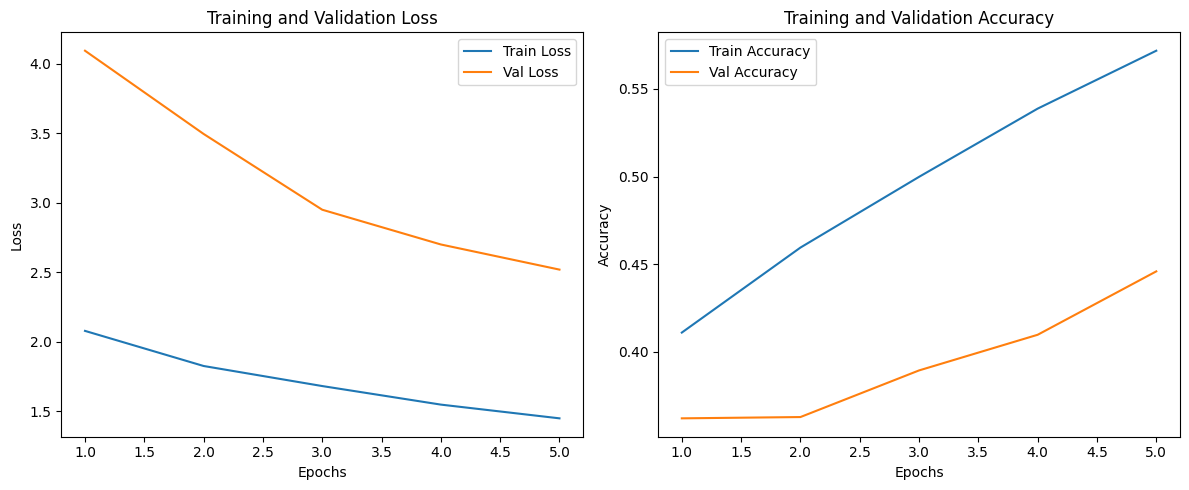

In [49]:
import matplotlib.pyplot as plt

# Create epoch numbers
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# -------- Loss Plot --------
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# -------- Accuracy Plot --------
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

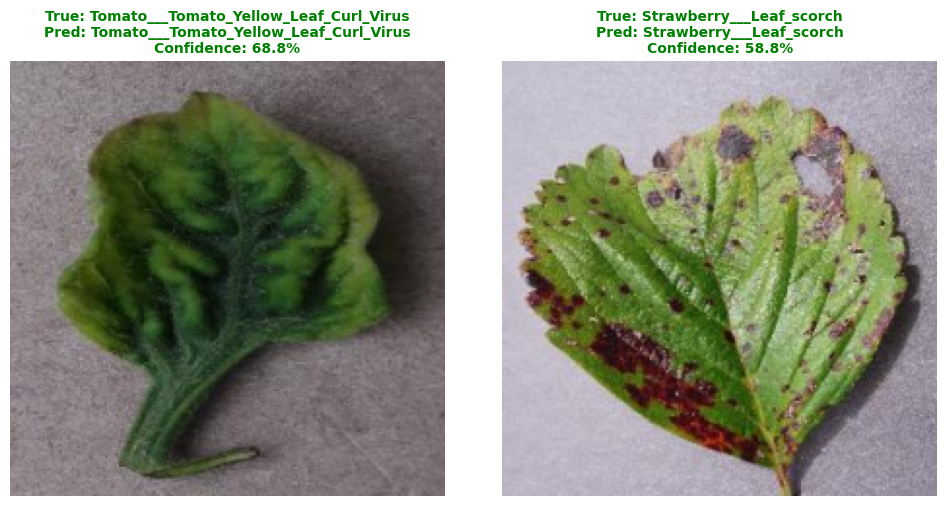

In [50]:
test_model_on_samples(
    model=model,
    dataset=val_dataset,
    class_names=class_names,
    num_samples=2,
    device=device
)

In [56]:
if val_acc > best_val_acc:
    best_val_acc = val_acc

    torch.save({
        "model_state_dict": model.state_dict(),
        "class_names": train_dataset.classes,
        "num_classes": num_classes
    }, "best_simplecnn_model.pth")

    print(f"✅ Best model saved! Val Acc: {val_acc*100:.2f}%")

In [57]:
if val_acc > best_val_acc:
    best_val_acc = val_acc

    torch.save({
        "model_state_dict": model.state_dict(),
        "class_names": train_dataset.classes,
        "num_classes": num_classes
    }, "best_simplecnn_model.pth")

    print(f"✅ Best model saved! Val Acc: {val_acc*100:.2f}%")

In [58]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [61]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": train_dataset.classes,
    "num_classes": num_classes
}, "best_simplecnn_model.pth")

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load full checkpoint dictionary
checkpoint = torch.load("best_simplecnn_model.pth", map_location=device)

# Extract information
class_names = checkpoint["class_names"]
num_classes = checkpoint["num_classes"]

# Recreate model
model = SimpleCNN(num_classes)

# Load only model weights
model.load_state_dict(checkpoint["model_state_dict"])

model = model.to(device)
model.eval()

print("✅ Model loaded successfully")

✅ Model loaded successfully


In [66]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder("PlantBot/Datasets/train", transform=transform)
val_dataset = datasets.ImageFolder("PlantBot/Datasets/val", transform=transform)

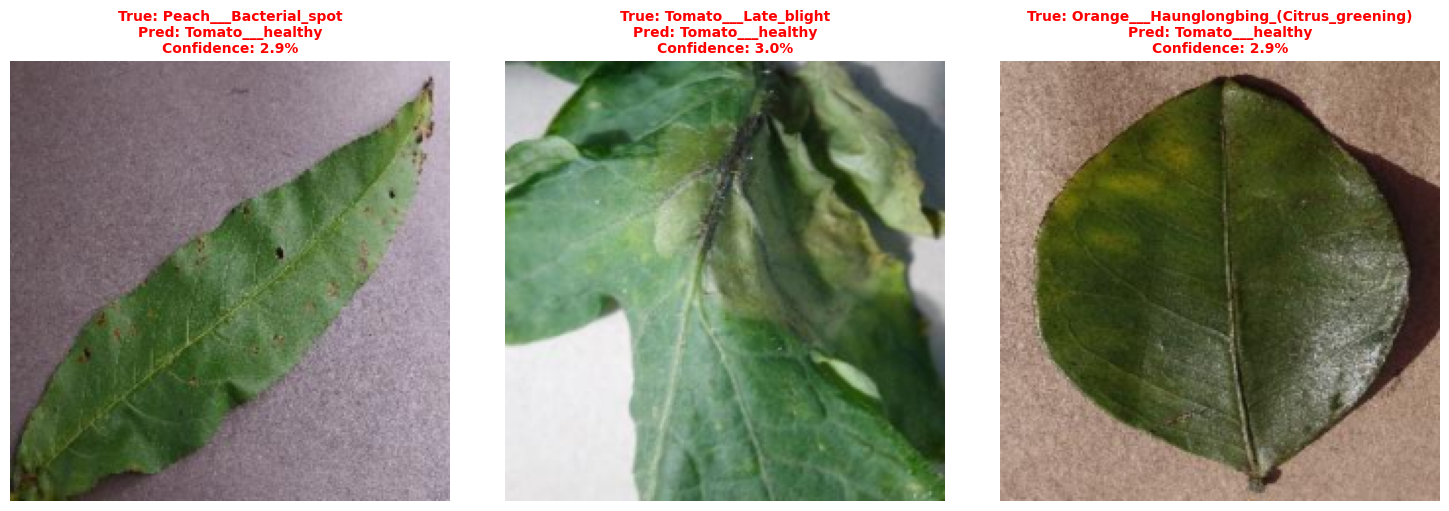

In [67]:
test_model_on_samples(model, val_dataset, class_names, num_samples=3, device=device)

In [70]:
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [71]:
print(train_dataset.classes)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [73]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": train_dataset.classes,
    "num_classes": num_classes
}, "best_model.pth")

In [74]:
checkpoint = torch.load("best_model.pth")
class_names = checkpoint["class_names"]

In [75]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [76]:
print("Index mapping:")
for i, name in enumerate(class_names):
    print(i, "→", name)

Index mapping:
0 → Apple___Apple_scab
1 → Apple___Black_rot
2 → Apple___Cedar_apple_rust
3 → Apple___healthy
4 → Blueberry___healthy
5 → Cherry_(including_sour)___Powdery_mildew
6 → Cherry_(including_sour)___healthy
7 → Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 → Corn_(maize)___Common_rust_
9 → Corn_(maize)___Northern_Leaf_Blight
10 → Corn_(maize)___healthy
11 → Grape___Black_rot
12 → Grape___Esca_(Black_Measles)
13 → Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 → Grape___healthy
15 → Orange___Haunglongbing_(Citrus_greening)
16 → Peach___Bacterial_spot
17 → Peach___healthy
18 → Pepper,_bell___Bacterial_spot
19 → Pepper,_bell___healthy
20 → Potato___Early_blight
21 → Potato___Late_blight
22 → Potato___healthy
23 → Raspberry___healthy
24 → Soybean___healthy
25 → Squash___Powdery_mildew
26 → Strawberry___Leaf_scorch
27 → Strawberry___healthy
28 → Tomato___Bacterial_spot
29 → Tomato___Early_blight
30 → Tomato___Late_blight
31 → Tomato___Leaf_Mold
32 → Tomato___Septoria_leaf_spo

In [78]:
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, pred = torch.max(probs, 1)

    print("Predicted index:", pred.item())
    print("Predicted class:", class_names[pred.item()])
    print("Confidence:", confidence.item() * 100)

    plt.imshow(image)
    plt.title(f"Prediction: {class_names[pred.item()]}\nConfidence: {confidence.item()*100:.2f}%")
    plt.axis("off")
    plt.show()

Predicted index: 37
Predicted class: Tomato___healthy
Confidence: 2.897539362311363


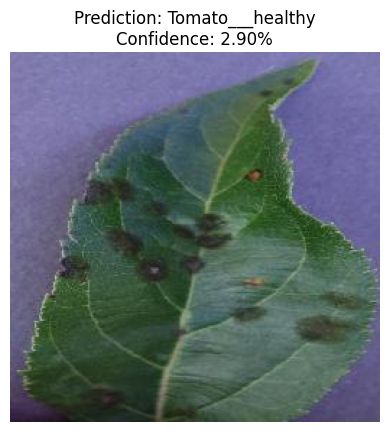

In [79]:
predict_image("/content/PlantBot/Datasets/train/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG")